<a href="https://colab.research.google.com/github/WahyuKhairi06/JaringanSyarafTiruan_WahyuKhairi_2311531009/blob/main/Tugas%20Akhir%20JST/Project_JST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install -q torch torchvision scikit-learn matplotlib

import os, zipfile, random, shutil
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models

from google.colab import drive
drive.mount('/content/drive')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [4]:
ZIP_DATASET = "/content/drive/MyDrive/Informatika/SMT 5/jaringan Syaraf tiruan/trash_image.zip"
EXTRACT_PATH = "/content/data_trash/"

os.makedirs(EXTRACT_PATH, exist_ok=True)

# Extract ZIP (skip jika sudah ada)
if not os.listdir(EXTRACT_PATH):
    with zipfile.ZipFile(ZIP_DATASET, 'r') as zf:
        zf.extractall(EXTRACT_PATH)
    print("Dataset extracted.")
else:
    print("Dataset already extracted.")

# Detect root folder (folder berisi subfolder kelas)
def find_root(path):
    items = [p for p in Path(path).iterdir() if p.is_dir()]
    for d in items:
        if any(f.suffix.lower() in ['.jpg','.jpeg','.png'] for f in d.iterdir()):
            return path
    return str(items[0])

DATA_ROOT = find_root(EXTRACT_PATH)
print("DATA ROOT:", DATA_ROOT)


Dataset extracted.
DATA ROOT: /content/data_trash/


In [5]:
IMG_SIZE = 224

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
    transforms.RandomErasing(p=0.2)
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
])


In [10]:
full_ds = datasets.ImageFolder(DATA_ROOT, transform=train_tf)
class_names = full_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

# Split dataset
train_size = int(0.7 * len(full_ds))
val_size = int(0.15 * len(full_ds))
test_size = len(full_ds) - train_size - val_size

train_ds, val_ds, test_ds = torch.utils.data.random_split(full_ds, [train_size, val_size, test_size])


# Get labels for the training subset using its indices into the full dataset
train_labels = [full_ds.targets[i] for i in train_ds.indices]

# Hitung jumlah gambar per kelas untuk train_ds
train_class_counts = np.bincount(train_labels, minlength=num_classes)
print("Jumlah per kelas (Train Set):", train_class_counts)

# Hitung weight per kelas (semakin kecil semakin besar bobot) untuk train_ds

train_weights = np.where(train_class_counts == 0, 0, 1.0 / train_class_counts)
train_sample_weights = [train_weights[label] for label in train_labels]

train_sampler = WeightedRandomSampler(train_sample_weights, num_samples=len(train_sample_weights), replacement=True)

# Re-initialize DataLoader with the corrected sampler
train_loader = DataLoader(train_ds, batch_size=32, sampler=train_sampler)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)


Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Jumlah per kelas (Train Set): [292 348 277 403 345 103]


In [7]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Ganti FC layer
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, num_classes)
)

model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)   # Label smoothing
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 131MB/s]


In [11]:
EPOCHS = 20
best_acc = 0
patience = 5
wait = 0

train_losses = []; val_losses = []
train_accs = []; val_accs = []

for epoch in range(EPOCHS):
    model.train()
    train_correct = 0; train_loss_sum = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * imgs.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

    train_loss = train_loss_sum / len(train_loader.dataset)
    train_acc = train_correct / len(train_loader.dataset)

    # Validation
    model.eval()
    val_correct = 0; val_loss_sum = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * imgs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    val_loss = val_loss_sum / len(val_loader.dataset)
    val_acc = val_correct / len(val_loader.dataset)

    scheduler.step(val_loss)

    train_losses.append(train_loss); val_losses.append(val_loss)
    train_accs.append(train_acc); val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    # Early stopping
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_resnet50.pth")
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("EARLY STOPPING TRIGGERED.")
            break


Epoch 1/20 | Train Acc: 0.7291 | Val Acc: 0.8364
Epoch 2/20 | Train Acc: 0.9027 | Val Acc: 0.8628
Epoch 3/20 | Train Acc: 0.9372 | Val Acc: 0.9103
Epoch 4/20 | Train Acc: 0.9412 | Val Acc: 0.9156
Epoch 5/20 | Train Acc: 0.9559 | Val Acc: 0.9208
Epoch 6/20 | Train Acc: 0.9672 | Val Acc: 0.8971
Epoch 7/20 | Train Acc: 0.9661 | Val Acc: 0.9024
Epoch 8/20 | Train Acc: 0.9819 | Val Acc: 0.9182
Epoch 9/20 | Train Acc: 0.9876 | Val Acc: 0.9420
Epoch 10/20 | Train Acc: 0.9836 | Val Acc: 0.9551
Epoch 11/20 | Train Acc: 0.9921 | Val Acc: 0.9235
Epoch 12/20 | Train Acc: 0.9943 | Val Acc: 0.9499
Epoch 13/20 | Train Acc: 0.9870 | Val Acc: 0.9367
Epoch 14/20 | Train Acc: 0.9949 | Val Acc: 0.9578
Epoch 15/20 | Train Acc: 0.9915 | Val Acc: 0.9551
Epoch 16/20 | Train Acc: 0.9949 | Val Acc: 0.9604
Epoch 17/20 | Train Acc: 0.9910 | Val Acc: 0.9551
Epoch 18/20 | Train Acc: 0.9915 | Val Acc: 0.9499
Epoch 19/20 | Train Acc: 0.9938 | Val Acc: 0.9551
Epoch 20/20 | Train Acc: 0.9932 | Val Acc: 0.9631


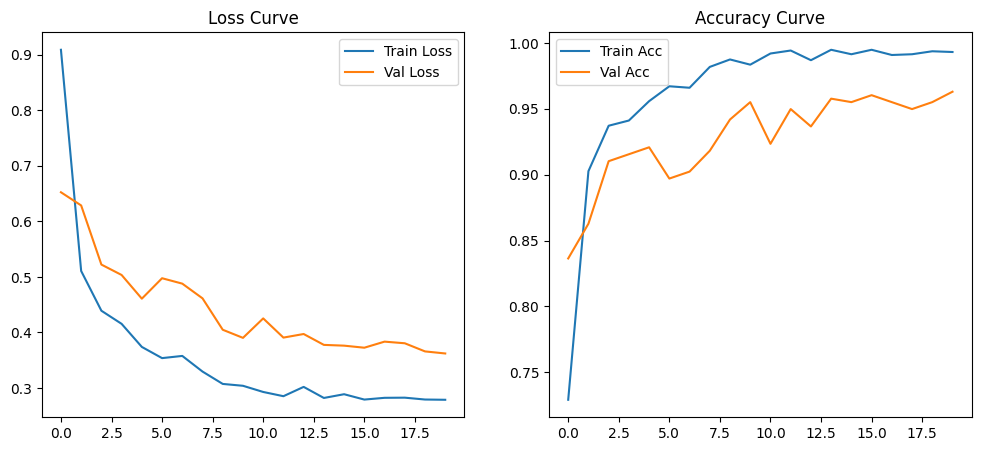

In [12]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend(); plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend(); plt.title("Accuracy Curve")

plt.show()



Classification Report:
              precision    recall  f1-score   support

   cardboard       0.94      1.00      0.97        46
       glass       0.98      0.92      0.95        90
       metal       0.97      0.94      0.95        66
       paper       0.97      0.95      0.96        96
     plastic       0.86      0.97      0.91        65
       trash       0.87      0.76      0.81        17

    accuracy                           0.94       380
   macro avg       0.93      0.92      0.93       380
weighted avg       0.94      0.94      0.94       380



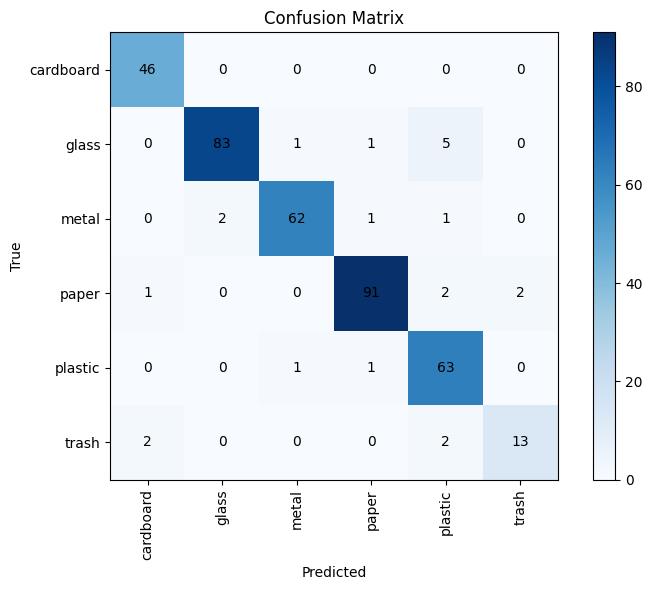

In [15]:
model.load_state_dict(torch.load("best_resnet50.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

# Tampilkan angka di setiap kotak
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.xticks(range(num_classes), class_names, rotation=90)
plt.yticks(range(num_classes), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


In [14]:
def predict_image(path):
    img = Image.open(path).convert("RGB")
    tf = val_tf
    x = tf(img).unsqueeze(0).to(device)

    with torch.no_grad():
        out = model(x)
        pred = out.argmax(1).item()

    plt.imshow(img)
    plt.title(f"Predicted: {class_names[pred]}")
    plt.axis('off')
    plt.show()

# Example:
# predict_image("/content/drive/MyDrive/test_image.jpg")
